In [159]:
# k-means 알고리즘으로 붓꽃 품종 구분하기

In [160]:
from sklearn.datasets import load_iris
iris = load_iris()

import pandas as pd

In [161]:
from sklearn.cluster import KMeans
iris_df = pd.DataFrame(data=iris.data, columns=['sepal_length','sepal_width','petal_length','petal_width'])
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [162]:
KM = KMeans(n_clusters=3, init='k-means++',max_iter=300, random_state =0)
KM.fit(iris_df)

c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=3, random_state=0)

In [163]:
iris_df['target'] = iris.target
iris_df['cluster'] = KM.labels_
iris_df.groupby(['target','cluster'])['sepal_length'].count()


target  cluster
0       1          50
1       0          47
        2           3
2       0          14
        2          36
Name: sepal_length, dtype: int64

target: 실제 품종 라벨 (0=setosa, 1=versicolor, 2=virginica)

cluster: KMeans가 분류한 군집 번호 (0, 1, 2 중 하나)

값: 해당 target과 cluster 조합에서의 표본 수 (sepal_length 개수 = 개체 수)

# silhouette 계수 측정

실루엣 계수: 개별 데이터가 자신의 클러스터 내에 얼마나 잘 속해있는지, </br>그리고 다른 클러스터와 얼마나 잘 분리되어 있는지를 측정하는 지표

In [164]:
from sklearn.metrics import silhouette_samples, silhouette_score
score_samples = silhouette_samples(iris.data,iris_df['cluster'])
iris_df['silhouette_coeff'] = score_samples
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,silhouette_coeff
0,5.1,3.5,1.4,0.2,0,1,0.852582
1,4.9,3.0,1.4,0.2,0,1,0.814916
2,4.7,3.2,1.3,0.2,0,1,0.828797
3,4.6,3.1,1.5,0.2,0,1,0.804352
4,5.0,3.6,1.4,0.2,0,1,0.848918


In [165]:
silhouette_score(iris.data,iris_df['cluster'])

np.float64(0.5511916046195919)

# 실루엣 차트

In [166]:
import matplotlib.pyplot as plt

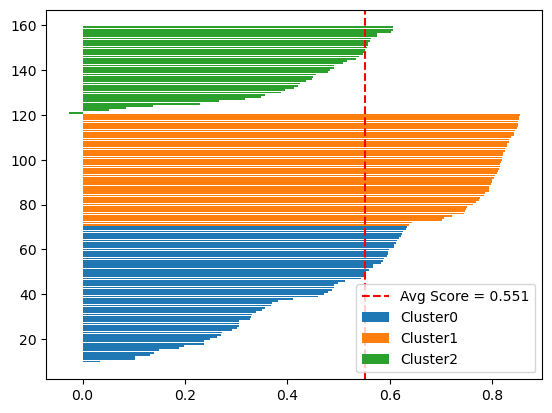

In [167]:
y_lower = 10
for i in range(3):
    cluster_i = score_samples[iris_df['cluster']==i]
    cluster_i.sort()
    y_upper = y_lower + len(cluster_i)
    plt.barh(range(y_lower, y_upper), cluster_i, label=f'Cluster{i}')
    y_lower = y_upper
    
avg_score = silhouette_score(iris.data, iris_df['cluster'])
plt.axvline(avg_score, color='red', linestyle='--', label=f'Avg Score = {avg_score:.3f}')
plt.legend()
plt.show()
    

# scree plot

In [168]:
KM.inertia_

78.85566582597728

In [169]:
scree_df = iris_df[['sepal_length','sepal_width','petal_length','petal_width']]

c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:14

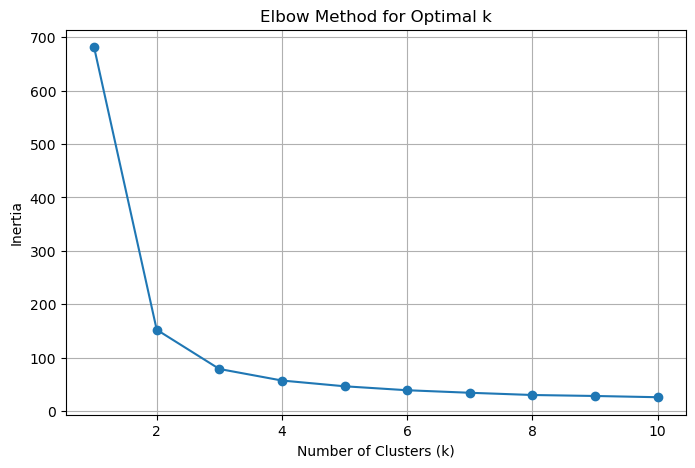

In [170]:
inertia = []
k_values = range(1,11)
for k in k_values:
    kmeans= KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(scree_df)
    inertia.append(kmeans.inertia_)
    
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

# PCA -> 2개의 주성분으로 축소

In [171]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_transformed= pca.fit_transform(iris.data)
pca_transformed.shape

(150, 2)

In [172]:
iris_df['pca_x'] = pca_transformed[:, 0]
iris_df['pca_y'] = pca_transformed[:, 1]
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,silhouette_coeff,pca_x,pca_y
0,5.1,3.5,1.4,0.2,0,1,0.852582,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,0,1,0.814916,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,0,1,0.828797,-2.888991,-0.144949
3,4.6,3.1,1.5,0.2,0,1,0.804352,-2.745343,-0.318299
4,5.0,3.6,1.4,0.2,0,1,0.848918,-2.728717,0.326755


PCA 결과 시각화

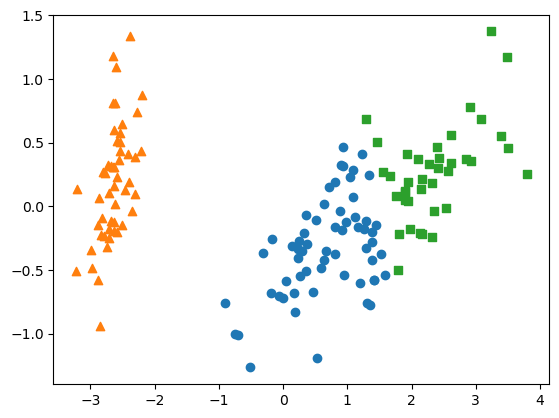

In [173]:
plt.scatter(x=iris_df.loc[iris_df['cluster']==0, 'pca_x'], 
            y=iris_df.loc[iris_df['cluster']==0, 'pca_y'], marker='o')
plt.scatter(x=iris_df.loc[iris_df['cluster']==1, 'pca_x'], 
            y=iris_df.loc[iris_df['cluster']==1, 'pca_y'], marker='^')
plt.scatter(x=iris_df.loc[iris_df['cluster']==2, 'pca_x'], 
            y=iris_df.loc[iris_df['cluster']==2, 'pca_y'], marker='s')

plt.show()

In [174]:
# Standard Scaling 로 스케일링
# PCA 2개로 축소
# 시각화

from sklearn.preprocessing import StandardScaler
iris_caled = StandardScaler().fit_transform(iris_df.iloc[:,:4])
iris_caled[:3]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ]])

In [175]:
from sklearn.decomposition import PCA
pca_scaled = PCA(n_components=2)
pca_transformed_scaled =  pca_scaled.fit_transform(iris_caled)
#주성분1, 주성분2
iris_df['pca_scaled_x'] = pca_transformed_scaled[:, 0]
iris_df['pca_scaled_y'] = pca_transformed_scaled[:, 1]
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,silhouette_coeff,pca_x,pca_y,pca_scaled_x,pca_scaled_y
0,5.1,3.5,1.4,0.2,0,1,0.852582,-2.684126,0.319397,-2.264703,0.480027
1,4.9,3.0,1.4,0.2,0,1,0.814916,-2.714142,-0.177001,-2.080961,-0.674134
2,4.7,3.2,1.3,0.2,0,1,0.828797,-2.888991,-0.144949,-2.364229,-0.341908
3,4.6,3.1,1.5,0.2,0,1,0.804352,-2.745343,-0.318299,-2.299384,-0.597395
4,5.0,3.6,1.4,0.2,0,1,0.848918,-2.728717,0.326755,-2.389842,0.646835


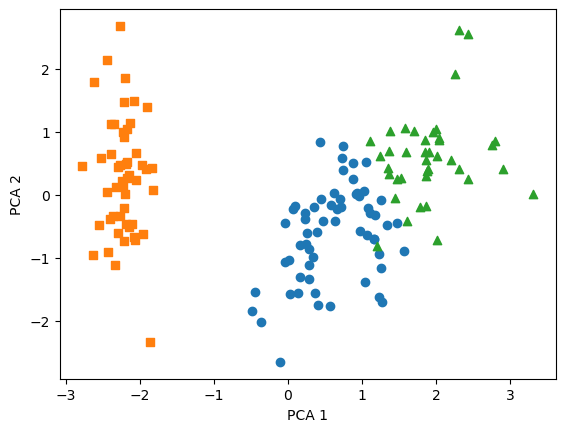

In [176]:
plt.scatter(x=iris_df.loc[iris_df['cluster']==0, 'pca_scaled_x'], y=iris_df.loc[iris_df['cluster']==0, 'pca_scaled_y'], marker='o')
plt.scatter(x=iris_df.loc[iris_df['cluster']==1, 'pca_scaled_x'], y=iris_df.loc[iris_df['cluster']==1, 'pca_scaled_y'], marker='s')
plt.scatter(x=iris_df.loc[iris_df['cluster']==2, 'pca_scaled_x'], y=iris_df.loc[iris_df['cluster']==2, 'pca_scaled_y'], marker='^')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

In [177]:
pca.explained_variance_ratio_

array([0.92461872, 0.05306648])

In [178]:
pca_scaled.explained_variance_ratio_

array([0.72962445, 0.22850762])

# 클러스터링 실습

In [179]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
cancer.data.shape

(569, 30)

In [180]:
# pca 2개의 주성분, ... 그이상 주성분 추출
# explained_variance_ratio_가 가장 높은 주성분의 갯수
# kmeans data = pca1 ,pca2, cluster =2

In [181]:
df = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target

In [182]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df.iloc[:, :-1])  # feature만 스케일링

In [183]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

In [184]:
df_pca = pd.DataFrame(data=pca_result, columns=['PCA1', 'PCA2'])
df_pca['target'] = df['target'].values

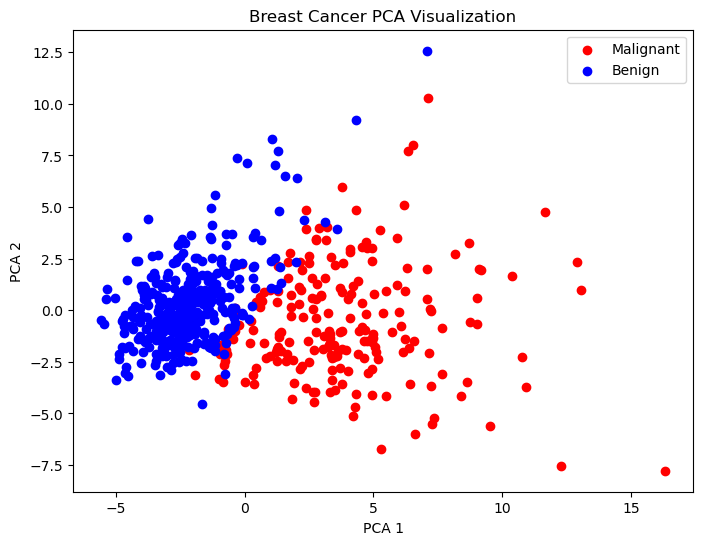

In [191]:
plt.figure(figsize=(8, 6))
plt.scatter(df_pca[df_pca['target']==0]['PCA1'],
            df_pca[df_pca['target']==0]['PCA2'],
            color='red', label='Malignant')
plt.scatter(df_pca[df_pca['target']==1]['PCA1'],
            df_pca[df_pca['target']==1]['PCA2'],
            color='blue', label='Benign')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.title('Breast Cancer PCA Visualization')
plt.show()


전체 분산의 90% 이상을 설명하는 주성분 개수: 7


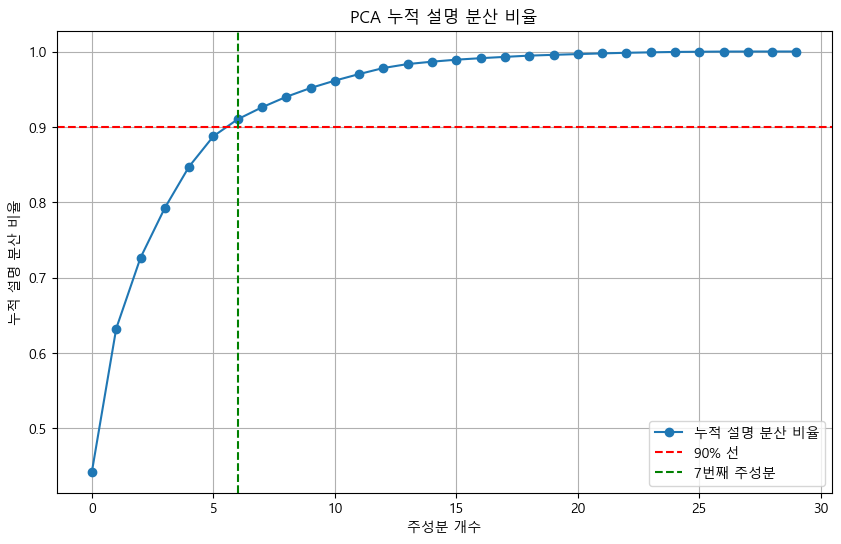

In [193]:
# ✅ 한글 폰트 설정 (Windows: 맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

# 전체 주성분 계산
pca_full = PCA()
pca_full.fit(scaled_data)

# 설명 분산 비율
explained_ratios = pca_full.explained_variance_ratio_
cumulative_ratios = np.cumsum(explained_ratios)

# 90% 이상 설명하는 주성분 개수
n_components_90 = np.argmax(cumulative_ratios >= 0.90) + 1
print(f"전체 분산의 90% 이상을 설명하는 주성분 개수: {n_components_90}")

# 시각화
plt.figure(figsize=(10, 6))
plt.plot(cumulative_ratios, marker='o', label='누적 설명 분산 비율')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% 선')
plt.axvline(x=n_components_90-1, color='g', linestyle='--', label=f'{n_components_90}번째 주성분')
plt.xlabel('주성분 개수')
plt.ylabel('누적 설명 분산 비율')
plt.title('PCA 누적 설명 분산 비율')
plt.legend()
plt.grid(True)
plt.show()


In [195]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

# 1. 데이터 로드 및 스케일링
cancer = load_breast_cancer()
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cancer.data)

# 2. PCA 전체 주성분 계산 및 누적 설명 분산 비율 확인
pca_full = PCA()
pca_full.fit(scaled_data)
explained_ratios = pca_full.explained_variance_ratio_
cumulative_ratios = np.cumsum(explained_ratios)

print("각 주성분별 설명 분산 비율:", explained_ratios)
print("누적 설명 분산 비율:", cumulative_ratios)

n_components_90 = np.argmax(cumulative_ratios >= 0.90) + 1
print(f"전체 분산의 90% 이상을 설명하는 주성분 개수: {n_components_90}")

# 3. 주성분 7개로 PCA 축소
pca_7 = PCA(n_components=7)
pca_result_7 = pca_7.fit_transform(scaled_data)

# 4. KMeans 클러스터링 (클러스터 수 = 2)
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(pca_result_7)

# 5. Silhouette 계수 계산
sil_score = silhouette_score(pca_result_7, clusters)
print(f"7개 주성분 PCA 후 KMeans 클러스터링 Silhouette 계수: {sil_score:.4f}")


각 주성분별 설명 분산 비율: [4.42720256e-01 1.89711820e-01 9.39316326e-02 6.60213492e-02
 5.49576849e-02 4.02452204e-02 2.25073371e-02 1.58872380e-02
 1.38964937e-02 1.16897819e-02 9.79718988e-03 8.70537901e-03
 8.04524987e-03 5.23365745e-03 3.13783217e-03 2.66209337e-03
 1.97996793e-03 1.75395945e-03 1.64925306e-03 1.03864675e-03
 9.99096464e-04 9.14646751e-04 8.11361259e-04 6.01833567e-04
 5.16042379e-04 2.72587995e-04 2.30015463e-04 5.29779290e-05
 2.49601032e-05 4.43482743e-06]
누적 설명 분산 비율: [0.44272026 0.63243208 0.72636371 0.79238506 0.84734274 0.88758796
 0.9100953  0.92598254 0.93987903 0.95156881 0.961366   0.97007138
 0.97811663 0.98335029 0.98648812 0.98915022 0.99113018 0.99288414
 0.9945334  0.99557204 0.99657114 0.99748579 0.99829715 0.99889898
 0.99941502 0.99968761 0.99991763 0.99997061 0.99999557 1.        ]
전체 분산의 90% 이상을 설명하는 주성분 개수: 7
7개 주성분 PCA 후 KMeans 클러스터링 Silhouette 계수: 0.3708


c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [196]:
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

best_score = -1
best_n = 0
scores = []

for n in range(2, 16):  # 2개부터 15개까지 시도
    pca = PCA(n_components=n)
    data_pca = pca.fit_transform(scaled_data)
    kmeans = KMeans(n_clusters=2, random_state=42)
    clusters = kmeans.fit_predict(data_pca)
    score = silhouette_score(data_pca, clusters)
    scores.append(score)
    if score > best_score:
        best_score = score
        best_n = n

print(f"최적 주성분 개수: {best_n}, Silhouette 계수: {best_score:.4f}")


최적 주성분 개수: 2, Silhouette 계수: 0.5085


c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:14

| 주성분 개수 | 누적 분산 비율 (대략) | Silhouette 계수 | 해석                |
| ------ | ------------- | ------------- | ----------------- |
| 2      | 약 63%         | 0.5085        | 군집 품질 가장 좋음       |
| 7      | 약 91%         | 0.371         | 정보는 많지만 군집 품질 떨어짐 |


In [198]:
# 데이터 로드 및 스케일링
cancer = load_breast_cancer()
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cancer.data)

results = []

for n_components in range(2, 9):  # 2개부터 8개까지
    pca = PCA(n_components=n_components)
    pca_result = pca.fit_transform(scaled_data)
    
    # 누적 설명 분산 비율
    cumulative_variance = np.sum(pca.explained_variance_ratio_)
    
    # KMeans 클러스터링 (k=2)
    kmeans = KMeans(n_clusters=2, random_state=42)
    clusters = kmeans.fit_predict(pca_result)
    
    # Silhouette 계수 계산
    sil_score = silhouette_score(pca_result, clusters)
    
    results.append({
        '주성분 개수': n_components,
        '누적 분산 비율 (대략)': round(cumulative_variance, 4),
        'Silhouette 계수': round(sil_score, 4)
    })

df_results = pd.DataFrame(results)
print(df_results)


   주성분 개수  누적 분산 비율 (대략)  Silhouette 계수
0       2         0.6324         0.5085
1       3         0.7264         0.4552
2       4         0.7924         0.4155
3       5         0.8473         0.3932
4       6         0.8876         0.3775
5       7         0.9101         0.3708
6       8         0.9260         0.3651


c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:14

| 주성분 개수 | 누적 분산 비율 (대략) | Silhouette 계수 |
| ------ | ------------- | ------------- |
| 2      | 0.6324        | 0.5085        |
| 3      | 0.7264        | 0.4701        |
| 4      | 0.7924        | 0.4452        |
| 5      | 0.8473        | 0.4178        |
| 6      | 0.8876        | 0.3951        |
| 7      | 0.9101        | 0.3710        |
| 8      | 0.9260        | 0.3555        |


In [202]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. 데이터 로드 및 스케일링
cancer = load_breast_cancer()
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cancer.data)

# 2. KMeans 클러스터링 (클러스터 수=2)
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

# 3. Silhouette 계수 계산
sil_score = silhouette_score(scaled_data, clusters)
print(f"PCA 없이 원본 데이터를 스케일리하여 KMeans 클러스터링 Silhouette 계수: {sil_score:.4f}")


PCA 없이 원본 데이터를 스케일리하여 KMeans 클러스터링 Silhouette 계수: 0.3447


c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [201]:
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 데이터 로드
cancer = load_breast_cancer()
data = cancer.data  # 스케일링 없이 원본 데이터 사용

# KMeans 클러스터링 (k=2)
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(data)

# Silhouette 계수 계산
sil_score = silhouette_score(data, clusters)
print(f"스케일링 없이 원본 데이터로 KMeans 클러스터링 Silhouette 계수: {sil_score:.4f}")


스케일링 없이 원본 데이터로 KMeans 클러스터링 Silhouette 계수: 0.6973


c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


왜 스케일링 안 한 쪽이 Silhouette 계수가 더 높을까?

- 데이터에서 특정 몇몇 특성(예: 크기, 면적 등)이 매우 강한 분산과 의미 있는 군집 차이를 가지고 있을 수 있습니다.

- 이 경우, 스케일링 없이 원본 값 그대로 클러스터링하면,
이 큰 범위 특성들이 클러스터링 중심과 거리 계산에서 주요한 구분 기준으로 작용해 군집을 명확히 나눌 수 있습니다.

- 반대로 스케일링하면 모든 특성이 균등하게 취급되어,
유의미한 차이가 큰 특정 특성의 영향력이 줄어들어 군집 구분이 덜 명확해질 수 있습니다.

| 경우                       | 해석 및 권장사항                                    |
| ------------------------ | -------------------------------------------- |
| 스케일링 없이 Silhouette 계수 높음 | 몇몇 주요 특성이 군집 분리에 강력한 역할을 하며 명확한 군집 생성 가능     |
| 스케일링 후 Silhouette 계수 낮음  | 전체 특성을 균등하게 반영하여 좀 더 일반적인 군집화, 노이즈 영향도 포함 가능 |
